# Quickstart: fit a mock galaxy

A star-forming galaxy with 12 broadband fluxes from GALEX, SDSS, 2MASS,
and WISE (UV through near-IR), fitted with Hamiltonian Monte Carlo on a
differentiable JAX forward model.

Deliberately minimal — the point is to show how *fast* the JIT-compiled
forward model and gradients are. Double power-law SFH that rises for ten
billion years, peaks about 3 Gyr before the epoch of observation, and
plateaus — still forming stars today. Single-component Calzetti dust
attenuation, baked-in nebular emission, free stellar metallicity, redshift
fixed at 0.05. Four free SFH parameters (alpha, beta, tau, log_total_mass;
the formation epoch is pinned at the Big Bang) plus dust V-band optical
depth and metallicity: six free parameters total. See `04_building_models.py`
for the recipe grammar and `02_sed_anatomy.py` for a panchromatic model with
dust IR re-emission, nebular, AGN, and IGM enabled.

In [1]:
# Shared notebook setup (see notebooks/_setup.py): quiets the framework notices
# that do not change the science, and loads the SSP grid.
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()

# Re-enable BakedInNebularWarning for this notebook: the baked-in SSP is the
# notebook's headline modeling assumption and the warning signals the frozen
# logU/logZ_gas assumptions to users.
import warnings
warnings.filterwarnings("default", message=".*BakedInBackend.*")

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Data,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    citations,
    cosmology,
    generate_mock,
    plot,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

## Stellar library and observation

An FSPS-generated SSP grid with nebular emission baked in at log(U) = −3.0
and solar gas-phase metallicity (Z_gas/Zsun = 1.0). Stellar metallicity is
free to vary; gas-phase metallicity is fixed by the grid. Per the project
contract, these are independent knobs, so the nebular contribution does not
respond to fitted stellar Z. `BakedInNebularWarning` on fit start marks this
assumption.

In [2]:
SSP_NAME = "prsc_miles_chabrier_wNE"
ssp = tengri.load_ssp(SSP_NAME, download=True)

FILTERS = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "2mass_j",
    "2mass_h",
    "2mass_ks",
    "wise_w1",
    "wise_w2",
]
obs = Observation(photometry=Photometry.from_names(FILTERS))

src/tengri/components/stellar/sps/dsps_wrapper.py:354: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only — adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))


## Build the model

Double power-law SFH with single-component Calzetti dust attenuation
(V-band optical depth τ_V free), baked-in nebular emission, and free stellar
metallicity; redshift fixed at z = 0.05: six free parameters. The DPL has
four free shape parameters (alpha, beta, tau_gyr, log_total_mass), giving
the SFR flexibility to rise, peak, and plateau while remaining star-forming
at the present epoch. The fifth, `age_gyr` — the formation epoch — is pinned
at 13.1 Gyr, the age of the universe at z = 0.05: formation at the Big Bang,
the same convention BAGPIPES uses for its `dblplaw` model. Pinning it also
removes a strong (age, tau, alpha) degeneracy from the posterior. Kept
minimal on purpose. Dust IR re-emission, full photoionized nebular grids,
and AGN are covered in `02_sed_anatomy.py`.

A single Calzetti screen reddens the entire stellar population uniformly.
Its simplicity makes it suitable for a quickstart example — the model
prioritizes interpretability and speed over the realism of a stratified
ISM.

In [3]:
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=WavePrecomp(),
    sfh={"type": "dpl", "all_params": FREE, "age_gyr": 13.1},  # formation at the Big Bang
    dust_attenuation={
        "type": "single_component",
        "law": "calzetti",
        "tau_v": Uniform(0.0, 4.0),
    },
    neb={"type": "ssp"},
    met={"logzsol": Uniform(-2.0, 0.2)},
    redshift=Fixed(0.05),
)

# The model that gets fitted. `ForwardModel` pairs the SED with the instrument
# that observed it; the observation is inherited from the SED, so there is
# nothing to re-declare here.
forward = ForwardModel.build(sed=sed_model)

print(sed_model.summary())
citations.print_citations(sed_model)

src/tengri/forward/sed_model.py:2871: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress when building via SEDModel.build: warnings.filterwarnings('ignore', message='BakedInBackend: nebular emission is baked'). (ionizing_source_warning='suppress' also works, but it is a BakedInBackend(...) constructor argument and the build grammar does not forward it.)
  self._nebular_backend = BakedInBackend()


Model  SFH: dpl
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     12 bands
  Redshift:    0.0500 (fixed)
  Dtype:       float64
  Fast path:   photometry LUT
  Components:  nebular=ssp

  Pipeline (3 components):
    1. stellar        [sfh_model=dpl, metallicity_model=delta, n_grid=256]
    2. nebular        [backend=baked_in]
    3. dust_attenuation [law=calzetti]

  Parameters:  6 free
──────────────────────────────────────────────────────────────────
Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
   

## Mock observation

The truth is an explicit double power-law: star formation rises for ten
billion years, peaks about 3 Gyr ago, then plateaus — the galaxy is still
forming stars today at ≈97% of its peak rate. The DPL turns over at cosmic
time T = τ·(β/α)^(1/(α+β)) after formation; with the formation epoch pinned
at the Big Bang in the build above, α = 0.5, β = 2.0 and
τ = 5.8 Gyr place that turnover 3 Gyr before the epoch of observation. The
shallow falling slope α is what buys the plateau. `generate_mock` returns
the noiseless model fluxes, Gaussian uncertainties at the requested S/N,
and a noisy realization.

In [4]:
key = jax.random.PRNGKey(6)
_, key_mock, key_fit = jax.random.split(key, 3)

truth = {
    "sfh_dpl_alpha": 0.5,  # falling slope: shallow => plateau after the peak
    "sfh_dpl_beta": 2.0,  # rising slope: SFR grows as T^2 at early times
    "sfh_dpl_tau_gyr": 5.8,  # places the turnover at lookback ~3 Gyr
    "sfh_dpl_log_total_mass": 10.0,
    "dust_tau_v": 0.3,
    "met_logzsol": -0.3,
}

# Verify the intended shape: star-forming, peak ~3 Gyr ago, plateau to today
truth_full_temp = {**sed_model.spec.get_fixed_values(), **truth}
pred_truth = sed_model.predict(truth_full_temp)
ssfr_truth = float(pred_truth.ssfr)
assert ssfr_truth > 1e-11, f"Truth is not star-forming: sSFR = {ssfr_truth:.3e} /yr (need > 1e-11 /yr)"

state_truth = sed_model.predict_state(truth_full_temp)
sfr_grid = np.asarray(state_truth.derived["sfr_history"])
t_lbt_grid = np.asarray(state_truth.derived["sfh_grid_lbt_yr"])
sfr_current = sfr_grid[np.argmin(np.abs(t_lbt_grid))]
assert sfr_current > 0.0, f"SFR at present is not positive: {sfr_current:.3e} Msun/yr"

# Peak lookback time ~3 Gyr, and a genuine plateau: SFR today within 70% of peak
lbt_peak_gyr = t_lbt_grid[np.argmax(sfr_grid)] / 1e9
assert 2.0 < lbt_peak_gyr < 4.0, f"SFH peak at {lbt_peak_gyr:.2f} Gyr lookback (want ~3 Gyr)"
plateau_ratio = sfr_current / sfr_grid.max()
assert plateau_ratio > 0.7, f"No plateau: SFR(now)/SFR(peak) = {plateau_ratio:.2f} (want > 0.7)"
print(
    f"  truth SFH: peak at lookback {lbt_peak_gyr:.2f} Gyr, "
    f"SFR(now)/SFR(peak) = {plateau_ratio:.2f}, sSFR = {ssfr_truth:.2e} /yr"
)

mock = generate_mock(sed_model, truth, key=key_mock, snr=30.0)
flux_obs = np.asarray(mock["flux_obs"])
noise = np.asarray(mock["noise"])

phot = obs.photometry
wave_eff_um = effective_wavelengths_um(phot)

  truth SFH: peak at lookback 2.98 Gyr, SFR(now)/SFR(peak) = 0.97, sSFR = 1.72e-10 /yr


## One-time JIT compile

Cold compile is a few seconds; warm cache is milliseconds. The difference
between first and second call below shows the cost of compilation alone.

In [5]:
import time

p0 = {**sed_model.spec.get_fixed_values(), **truth}
predict_phot = jax.jit(sed_model.predict_photometry)
grad_fn = jax.jit(
    jax.grad(lambda p: 0.5 * jnp.sum(((sed_model.predict_photometry(p) - flux_obs) / noise) ** 2))
)

t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   warm:       {time.perf_counter() - t:8.4f} s")

t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  warm:       {time.perf_counter() - t:8.4f} s")

  forward kernel   first call:   0.4444 s  (compile + run)
  forward kernel   warm:         0.0006 s


  ∇log-likelihood  first call:   0.8363 s  (compile + run)
  ∇log-likelihood  warm:         0.0008 s


## Fit

`forward.fit(Data(photometry=(flux, noise)), ...)` is the whole interface: wrap
the data in the `Data` container with the channel name (here, `photometry`), hand
it to the fitter, and pick a method. The channel is explicit and unambiguous.

Multi-start ADAM for the MAP point estimate, then Hamiltonian Monte Carlo
with four parallel chains via `jax.vmap` for the full posterior. The
`n_restarts=8` parameter runs eight random inits in parallel and keeps the
lowest-loss one, then the chains are seeded from that MAP point
(`init_from=map_result`).

Three settings make the posterior cheap. `init_from=map_result` starts the
chains at a high-probability point, so a short warm-up suffices where a cold
start needs many hundreds of steps. `precondition=True` builds an analytic
metric from the model's own Hessian at the MAP point and samples in whitened
coordinates — the posterior is unchanged (the map is linear); only the
geometry the integrator sees improves. And on that whitened geometry a
*fixed* trajectory of 50 leapfrog steps spans the posterior, so plain HMC
(`mcmc_hmc`) replaces NUTS: no tree building, every gradient evaluation
spent on a draw. (NUTS — `method="mcmc_nuts"` — tunes the trajectory length
automatically and is the safer default when you have not measured your
model; here it costs the same wall for a quarter of the effective samples.)
The diagnostics are printed below rather than hidden — read divergences
together with R̂.

In [6]:
data = Data(photometry=(flux_obs, noise))
map_kwargs = dict(method="map", n_restarts=8, n_steps=500)
hmc_kwargs = dict(
    method="mcmc_hmc",
    n_warmup=200,
    n_samples=300,
    n_chains=4,
    n_burnin=0,
    n_leapfrog_steps=50,
    dense_mass_matrix=False,
    target_accept_rate=0.85,
    precondition=True,  # sample in whitened coordinates (metric from the MAP-point Hessian)
)

# Kernel compilation depends on the model shape, not on the galaxy, and
# persists in the on-disk cache — pay it once by fitting a throwaway prior
# draw. Everything galaxy-dependent stays inside the timed fits below: the
# MAP optimization, the Hessian metric, the warm-up adaptation (step size and
# mass matrix are tuned to *this* posterior), and the sampling itself.
key_wt, key_wm, key_wf = jax.random.split(jax.random.PRNGKey(0), 3)
warm_mock = generate_mock(sed_model, sed_model.spec.sample(key_wt), key=key_wm, snr=30.0)
warm_data = Data(photometry=(np.asarray(warm_mock["flux_obs"]), np.asarray(warm_mock["noise"])))
warm_map = forward.fit(warm_data, key=key_wf, **map_kwargs)
_ = forward.fit(warm_data, key=key_wf, init_from=warm_map, **hmc_kwargs)

t = time.perf_counter()
map_result = forward.fit(data, key=key_fit, **map_kwargs)
print(f"  MAP wall:  {time.perf_counter() - t:6.2f} s")

t = time.perf_counter()
posterior = forward.fit(data, key=key_fit, init_from=map_result, **hmc_kwargs)
print(f"  HMC wall (adapt + sample; 4 chains × 300 = 1200 draws): {time.perf_counter() - t:6.2f} s")
posterior.summary()

# Convergence: read R̂ together with the divergence count — divergent
# transitions bias the draws, and R̂ alone cannot see a frozen chain. For
# publication-grade intervals insist on R̂ < 1.01 (raise `n_samples`).
rhat = posterior.rhat()
ess = posterior.effective_sample_size()
print(
    f"\n  max split-R̂ = {max(float(v) for v in rhat.values()):.4f}"
    f"    divergences = {posterior.diagnostics.get('n_divergent', 'n/a')}"
    f"    min ESS = {min(float(v) for v in ess.values()):.0f}"
)

  MAP (ADAM x8 restarts) complete in 1.2s, best loss=6.0029 (restart 3; worst finite=6.9)


src/tengri/inference/backends/mcmc/hmc.py:325: DeadFitWarning: dead fit: parameter(s) 'dust_Rv', 'dust_bump_strength', 'dust_delta', 'dust_f_obscuration', 'dust_slope', 'met_alpha_fe', 'met_logzsol_scatter', 'noise_dof', 'noise_frac_cal', 'redshift', 'sfh_dpl_age_gyr', 'sigma_v_kms' have 1 unique draw in 300 samples. R-hat cannot detect this. Remedies: shorter warmup, lower target_accept_rate, smaller step_size, or dense_mass_matrix=False (issue #1999).
  return Posterior(


  MAP (ADAM x8 restarts) complete in 0.5s, best loss=3.5288 (restart 7; worst finite=3.7)
  MAP wall:    0.61 s


  HMC wall (adapt + sample; 4 chains × 300 = 1200 draws):  11.44 s
Posterior  method: HMC (BlackJAX)  samples: 1200  wall_time: 11.3s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_bump_strength              0.0000    0.0000    0.0000       —
  dust_delta                      0.0000    0.0000    0.0000       —
  dust_f_obscuration              0.0000    0.0000    0.0000       —
  dust_slope                     -0.7000   -0.7000   -0.7000       —
  dust_tau_v                      0.3003    0.2450    0.3543       —
  met_alpha_fe                    0.0000    0.0000    0.0000       —
  met_logzsol                    -0.3153   -0.3779   -0.2510       —
  met_logzsol_scatter             0.1000    0.1000    0.1000       —
  noise_dof                       0.0000  

The fit recovers the mock truth: well-constrained parameters (stellar mass,
dust, metallicity) land on the input values. The SFH *shape* parameters are
broader — twelve broadband fluxes only weakly constrain how the plateau was
reached — but the posteriors are unimodal and contain the truth.

Derived physical scalars — stellar mass, SFR, sSFR — rolled up from the
SFH integral, with the input truth in the first column.

In [7]:
N_DRAWS = 200
draws = posterior.resample(jax.random.PRNGKey(11), n=N_DRAWS)
fixed = sed_model.spec.get_fixed_values()


def draw_dicts(n):
    for i in range(n):
        yield {**fixed, **{k: float(v[i]) for k, v in draws.items()}}


DERIVED_KEYS = ("stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr")

# `posterior.properties` is the property catalog lifted over the sample axis:
# the same names a `Prediction` uses, one axis wider, evaluated in memory-bounded
# chunks. It reads every draw the chain produced rather than the 200 resampled
# here, and `.ci()` returns the 16/50/84 interval directly.
truth_full = {**fixed, **truth}
truth_derived = sed_model.predict(truth_full).properties

print(f"{'quantity':<14}{'truth':>14}{'p16':>14}{'p50':>14}{'p84':>14}")
print("-" * 70)
for k in DERIVED_KEYS:
    lo, med, hi = posterior.properties.ci(k)
    t = truth_derived.get(k)
    tstr = "—" if t is None else f"{float(t):.3e}"
    print(f"{k:<14}{tstr:>14}{lo:>14.3e}{med:>14.3e}{hi:>14.3e}")

quantity               truth           p16           p50           p84
----------------------------------------------------------------------


stellar_mass       1.000e+10     8.821e+09     9.789e+09     1.088e+10
sfr_100myr         1.057e+00     9.262e-01     1.040e+00     1.179e+00


sfr_10myr          1.056e+00     9.234e-01     1.038e+00     1.179e+00
ssfr               1.721e-10     1.409e-10     1.720e-10     2.115e-10


## Posterior SED

Full posterior spectrum in the background (median + 68 % band), truth
dashed, observed photometry with error bars, residuals against the
posterior median below.

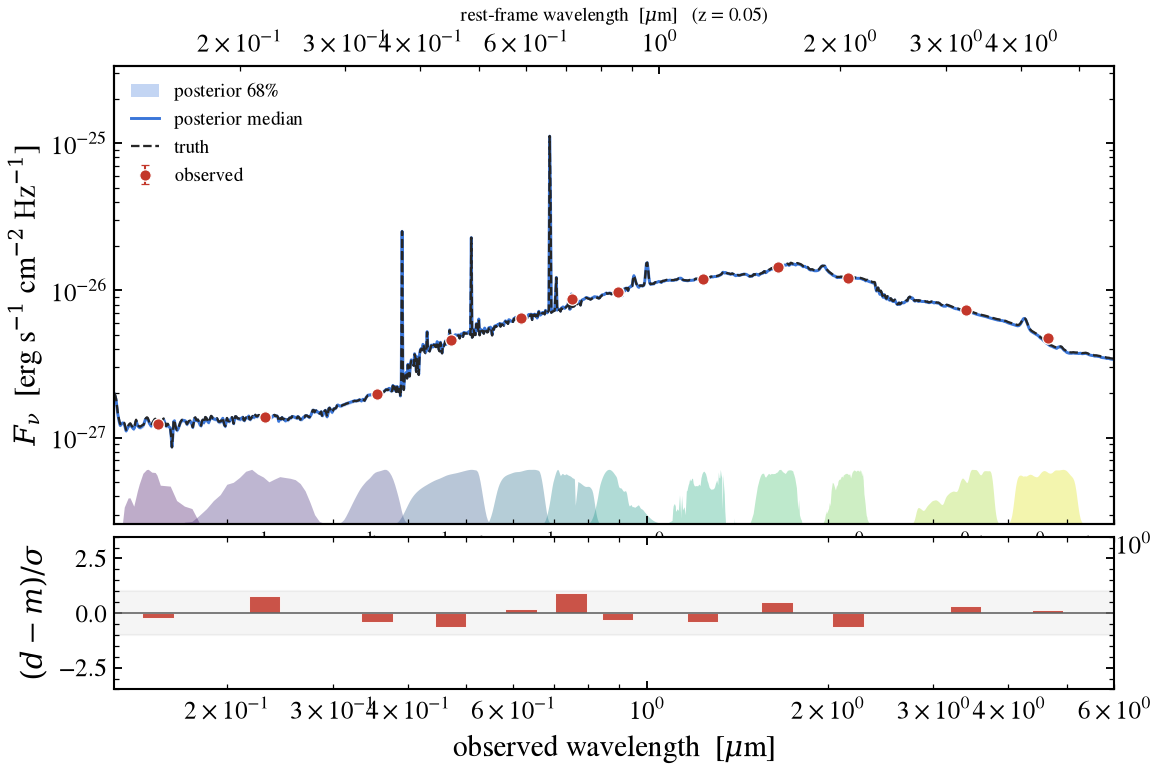

In [8]:
WAVE_OBS = np.geomspace(1300.0, 6e4, 1200)  # 0.13–6 μm covers GALEX → WISE W2
z_truth = float(truth_full["redshift"])
dl_cm = cosmology.luminosity_distance(z_truth)


def obs_fnu(params):
    pred = sed_model.predict(params)
    lnu_interp = np.interp(
        WAVE_OBS / (1.0 + z_truth), np.asarray(sed_model.wavelengths), np.asarray(pred.rest_sed())
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu_interp), dl_cm, z_truth))


spec_draws = np.stack([obs_fnu(p) for p in draw_dicts(40)])
spec_lo, spec_med, spec_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
spec_truth = obs_fnu(truth_full)

# Posterior photometry via ``predict_photometry`` — the same WavePrecomp LUT
# path the fit used. It serves the filter fluxes straight from the SSP × filter
# table without materializing the full-resolution SED cube, so the posterior
# draws map cheaply (no vmap chunking needed).
phot_draws = np.stack([np.asarray(sed_model.predict_photometry(p)) for p in draw_dicts(N_DRAWS)])
phot_med = np.median(phot_draws, axis=0)

fig = plt.figure(figsize=(8.6, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.04)
ax, ax_res = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

wave_um = WAVE_OBS / 1e4

# Filter transmission curves shaded behind the spectrum — Bagpipes/Prospector
# style. Use the matplotlib default qualitative palette across bands.
band_palette = plt.cm.viridis(np.linspace(0.05, 0.95, len(phot.filter_waves)))
ymin, ymax = 0.3 * spec_truth.min(), 3 * spec_truth.max()
for fw, ft, color in zip(phot.filter_waves, phot.filter_trans, band_palette):
    fw_um = np.asarray(fw) / 1e4
    ft_norm = np.asarray(ft) / np.max(ft)
    # Map transmission to the bottom 12 % of the log-y axis.
    band = ymin * (ymax / ymin) ** (0.12 * ft_norm)
    ax.fill_between(fw_um, ymin, band, color=color, alpha=0.35, lw=0)

ax.fill_between(wave_um, spec_lo, spec_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax.plot(wave_um, spec_med, color=C_POST, lw=1.4, label="posterior median")
ax.plot(wave_um, spec_truth, color=C_TRUTH, lw=1.1, ls="--", label="truth")
ax.errorbar(
    wave_eff_um,
    flux_obs,
    yerr=noise,
    fmt="o",
    color=C_DATA,
    ms=5.5,
    capsize=2,
    elinewidth=1.0,
    mec="white",
    mew=0.6,
    label="observed",
    zorder=5,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_xlim(wave_um.min(), wave_um.max())
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)

# Rest-frame wavelength axis on top.
ax_rest = ax.twiny()
ax_rest.set_xscale("log")
ax_rest.set_xlim(wave_um.min() / (1.0 + z_truth), wave_um.max() / (1.0 + z_truth))
ax_rest.set_xlabel(rf"rest-frame wavelength  [$\mu$m]   (z = {z_truth:.2f})", fontsize=9)

resid = (flux_obs - phot_med) / noise
ax_res.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_res.axhline(0, color="0.4", lw=0.8)
ax_res.bar(
    wave_eff_um,
    resid,
    width=wave_eff_um * 0.12,
    color=C_DATA,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax_res.set_xscale("log")
ax_res.set_xlim(wave_um.min(), wave_um.max())
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_res.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "00_posterior_sed.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "00_posterior_sed.pdf", bbox_inches="tight")

## Star-formation history

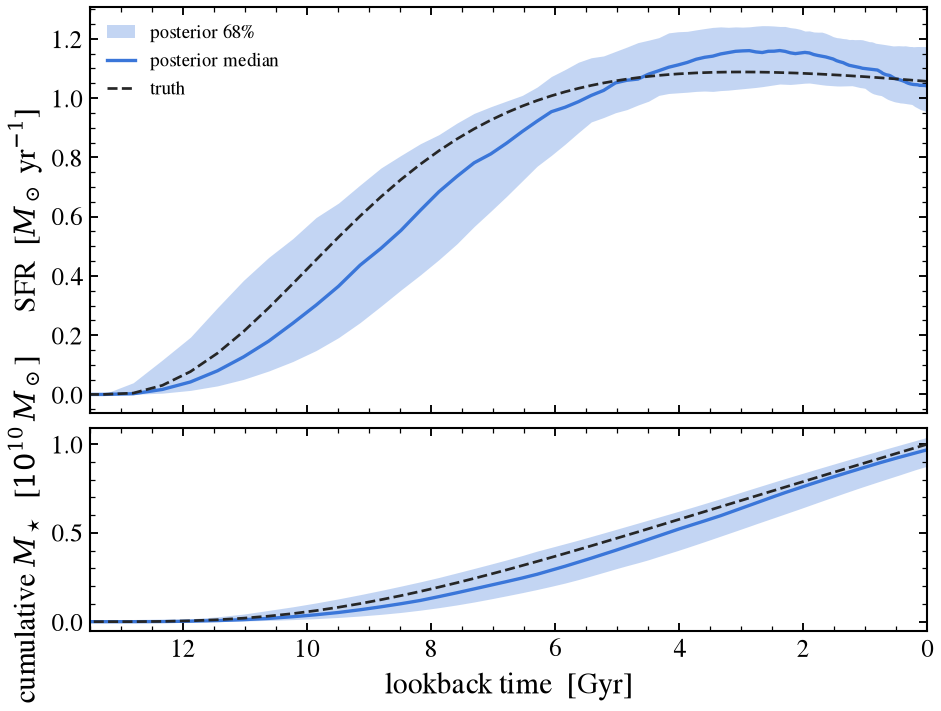

In [9]:
def sfh(p):
    s = sed_model.predict_state(p)
    return (
        np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9,
        np.asarray(s.derived["sfr_history"]),
    )


sfr_draws, lbt = [], None
for p in draw_dicts(80):
    lbt_i, sfr_i = sfh(p)
    sfr_draws.append(sfr_i)
    if lbt is None:
        lbt = lbt_i
sfr_draws = np.stack(sfr_draws)
sfr_lo, sfr_med, sfr_hi = np.percentile(sfr_draws, [16, 50, 84], axis=0)
lbt_t, sfr_t = sfh(truth_full)

# Two-panel SFH: SFR(t) on top, cumulative formed mass on bottom.
fig_sfh, (ax_sfh, ax_cum) = plt.subplots(
    2, 1, figsize=(7.2, 5.4), sharex=True, gridspec_kw=dict(height_ratios=[2, 1], hspace=0.05)
)

ax_sfh.fill_between(lbt, sfr_lo, sfr_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax_sfh.plot(lbt, sfr_med, color=C_POST, lw=1.6, label="posterior median")
ax_sfh.plot(lbt_t, sfr_t, color=C_TRUTH, ls="--", lw=1.3, label="truth")
ax_sfh.set_ylabel(r"SFR  [$M_\odot$ yr$^{-1}$]")
ax_sfh.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax_sfh.get_xticklabels(), visible=False)

# Cumulative formed stellar mass — integrate SFR(t) backwards from now.
dt_yr = np.gradient(lbt * 1e9)  # Gyr → yr, signed
cum_draws = np.flip(np.cumsum(np.flip(sfr_draws * dt_yr[None, :], axis=1), axis=1), axis=1)
cum_lo, cum_med, cum_hi = np.percentile(cum_draws, [16, 50, 84], axis=0)
cum_truth = np.flip(np.cumsum(np.flip(sfr_t * dt_yr), axis=0), axis=0)
ax_cum.fill_between(lbt, cum_lo / 1e10, cum_hi / 1e10, color=C_POST, alpha=0.30, lw=0)
ax_cum.plot(lbt, cum_med / 1e10, color=C_POST, lw=1.6)
ax_cum.plot(lbt_t, cum_truth / 1e10, color=C_TRUTH, ls="--", lw=1.3)
ax_cum.set_ylabel(r"cumulative $M_\star$  [$10^{10}\,M_\odot$]")

for axx in (ax_sfh, ax_cum):
    axx.invert_xaxis()
    axx.set_xlim(13.5, 0)
ax_cum.set_xlabel("lookback time  [Gyr]")

fig_sfh.savefig(FIG_DIR / "00_sfh.png", dpi=300, bbox_inches="tight")
fig_sfh.savefig(FIG_DIR / "00_sfh.pdf", bbox_inches="tight")

## Corner

Free parameters plus derived quantities (`stellar_mass`, `sfr_100myr`,
`sfr_10myr`, in log₁₀), truth dashed.

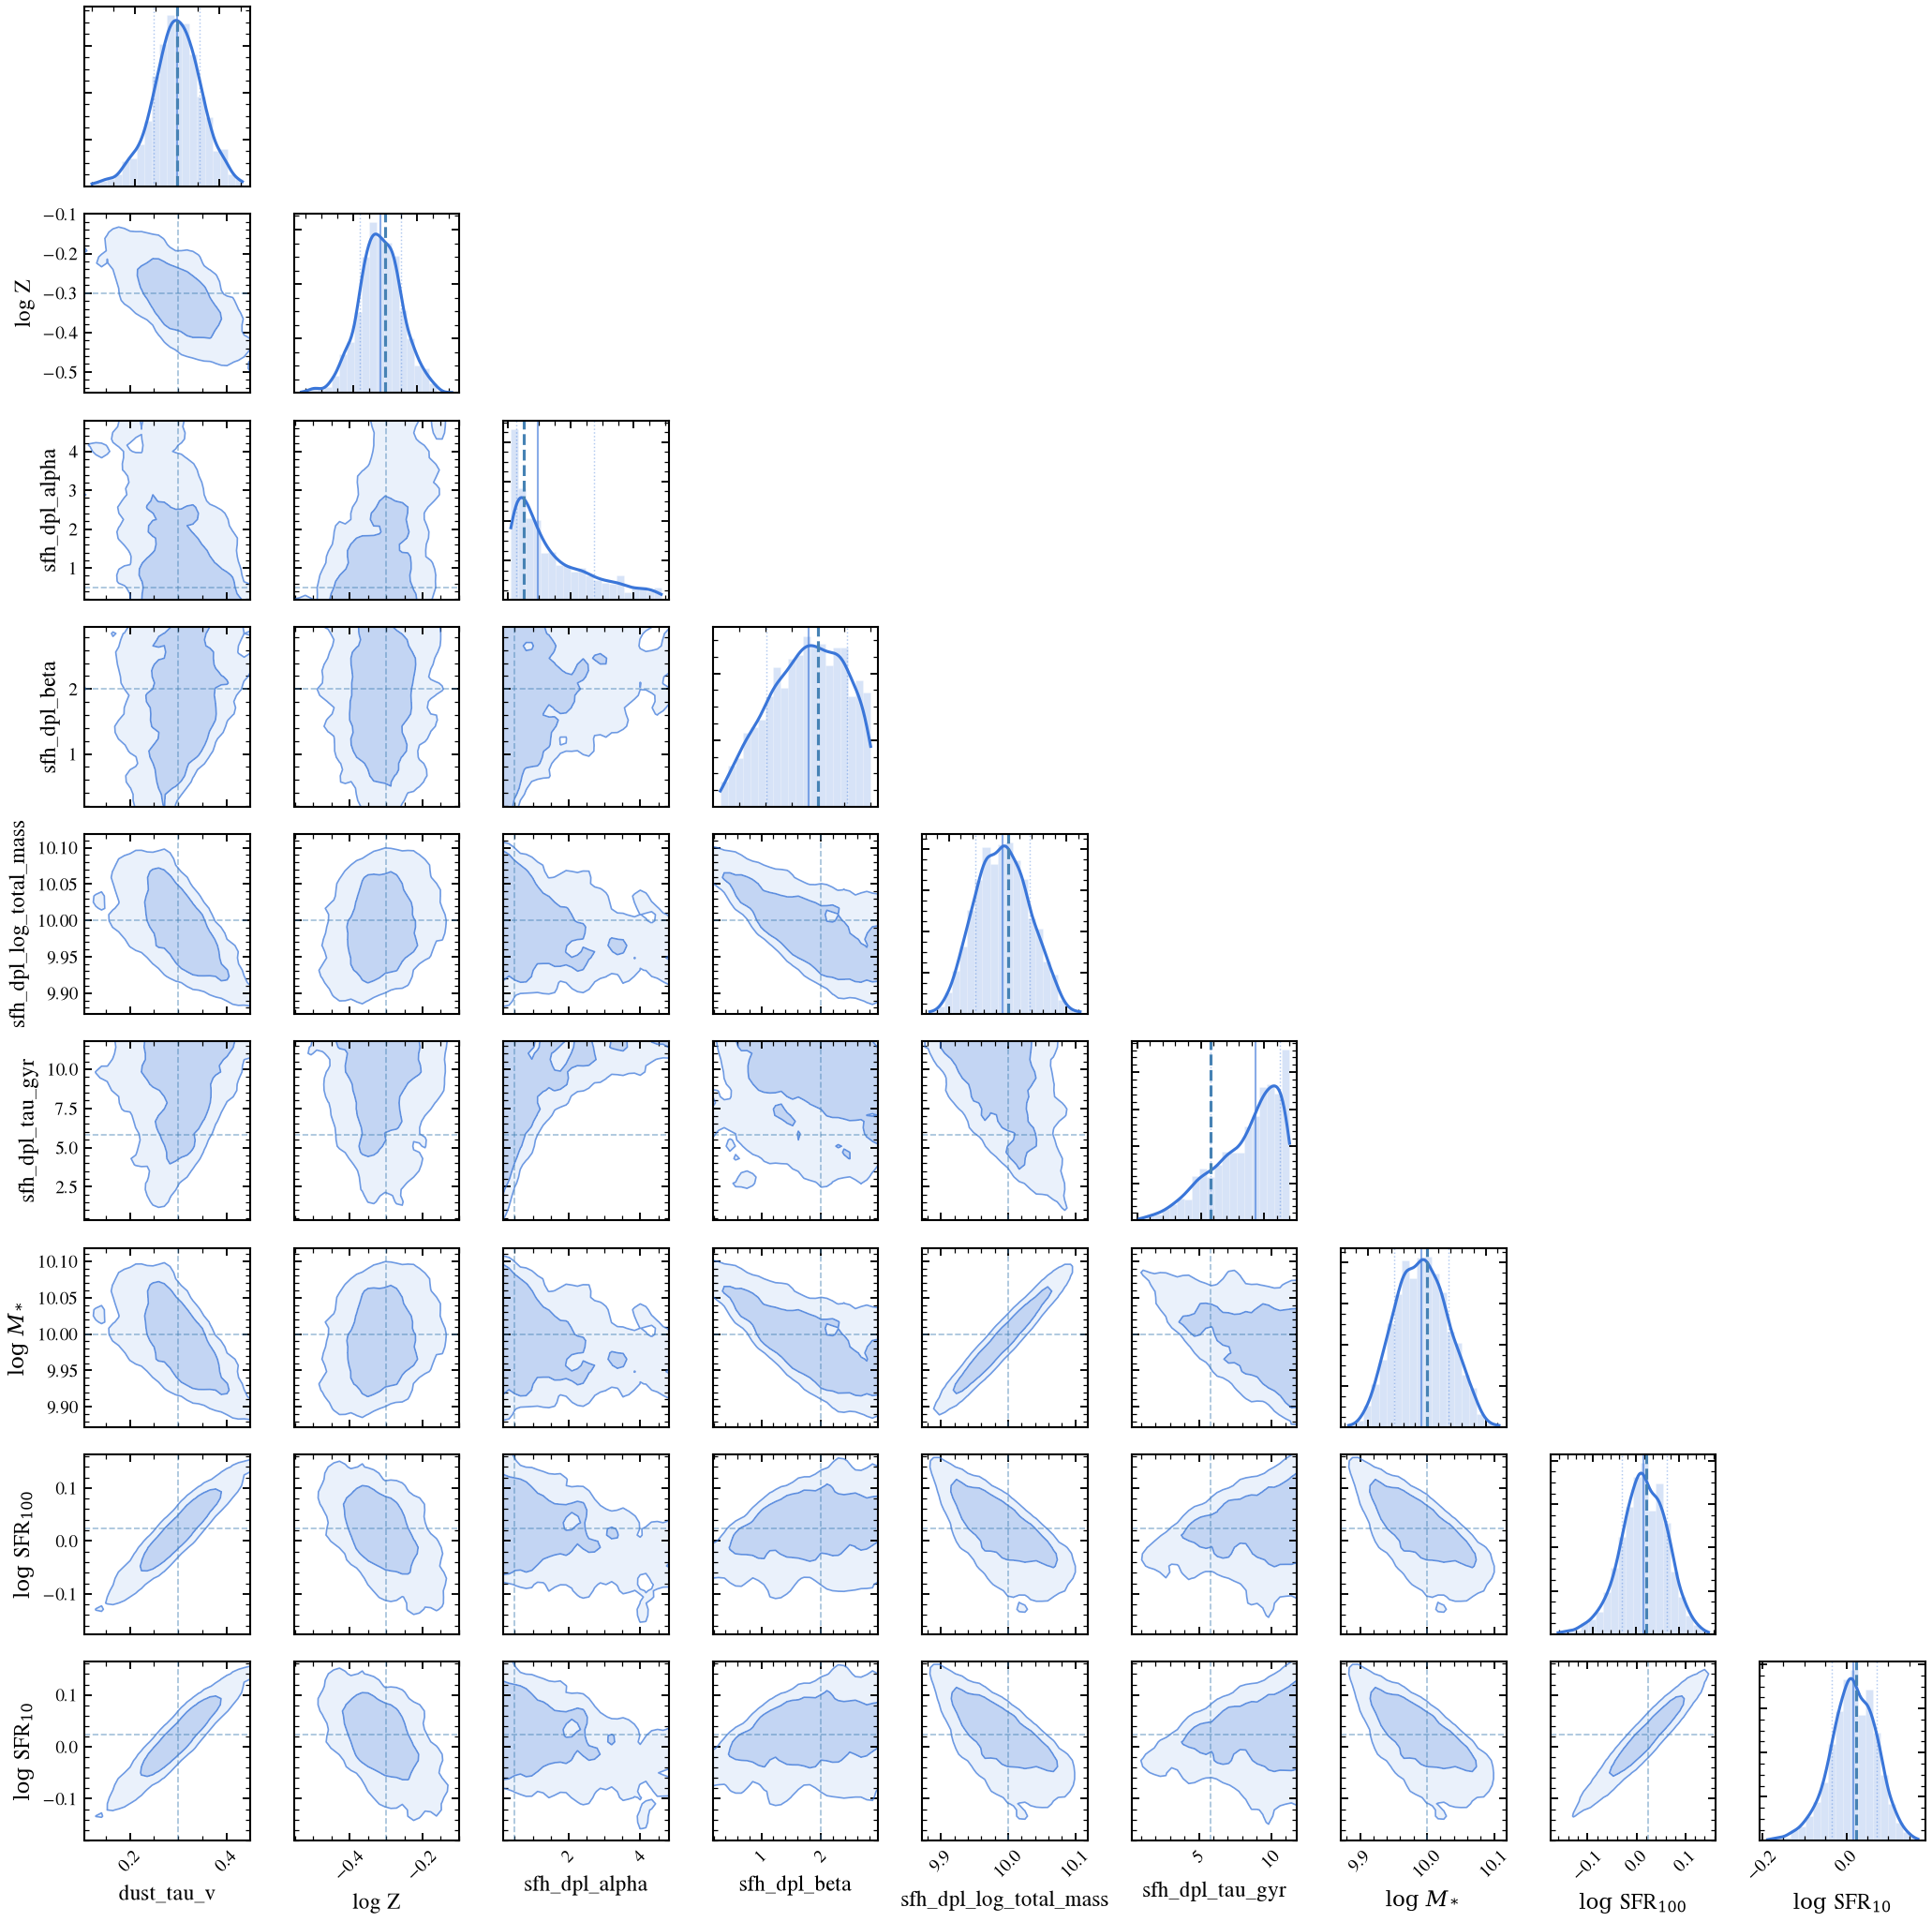

In [10]:
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "00_corner.png", dpi=300, bbox_inches="tight")
fig_corner.savefig(FIG_DIR / "00_corner.pdf", bbox_inches="tight")